In [1]:
!pip install opencv-python numpy matplotlib

(np.float64(-0.5), np.float64(479.5), np.float64(269.5), np.float64(-0.5))

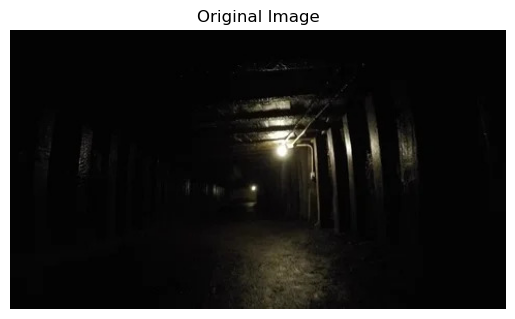

In [17]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("image2.jpg")

# Convert BGR → RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# SINGLE SCALE RETINEX 

In [18]:
import numpy as np

def SSR(img, sigma):
    img = img.astype(np.float32) + 1.0   # avoid log(0)
    
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    
    retinex = np.log(img) - np.log(blur)
    
    return retinex

(np.float64(-0.5), np.float64(479.5), np.float64(269.5), np.float64(-0.5))

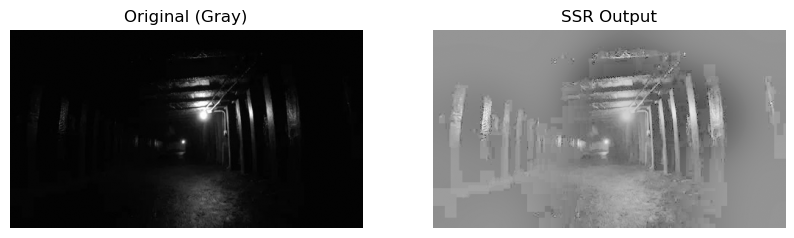

In [19]:
# Convert image to grayscale (simpler for now)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Apply SSR
ssr_result = SSR(gray, sigma=30)

# Normalize for display
ssr_result = cv2.normalize(ssr_result, None, 0, 255, cv2.NORM_MINMAX)
ssr_result = np.uint8(ssr_result)

# Show results
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original (Gray)")
plt.imshow(gray, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("SSR Output")
plt.imshow(ssr_result, cmap='gray')
plt.axis("off")

# MULTI-SCALE RETINEX

In [20]:
def MSR(img):
    sigmas = [15, 80, 250]   # multiple scales
    msr = np.zeros_like(img, dtype=np.float32)

    for s in sigmas:
        msr += SSR(img, s)

    msr = msr / len(sigmas)
    return msr

(np.float64(-0.5), np.float64(479.5), np.float64(269.5), np.float64(-0.5))

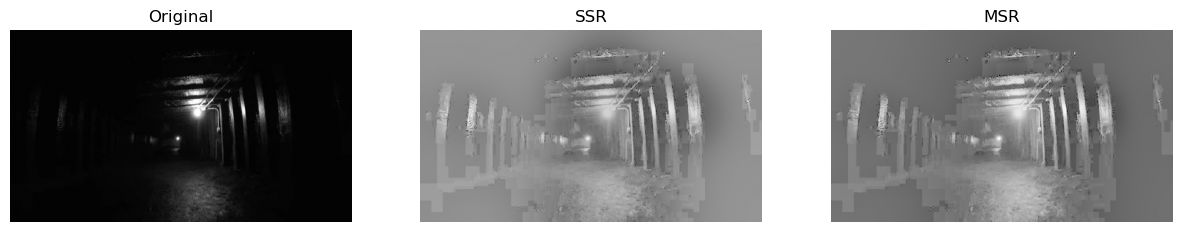

In [21]:
# Apply MSR
msr_result = MSR(gray)

# Normalize
msr_result = cv2.normalize(msr_result, None, 0, 255, cv2.NORM_MINMAX)
msr_result = np.uint8(msr_result)

# Show comparison
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(gray, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("MSR")
plt.imshow(msr_result, cmap='gray')
plt.axis("off")

# MSR+CLAHE

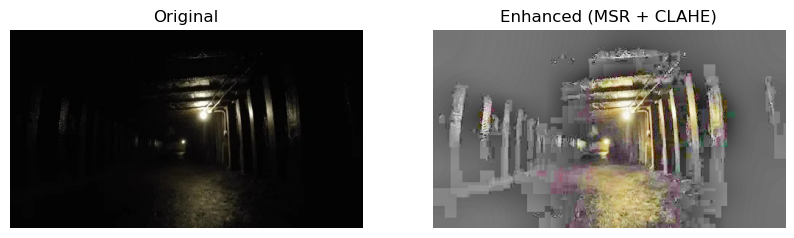

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Single Scale Retinex
def SSR(channel, sigma):
    channel = channel.astype(np.float32) + 1.0  # avoid log(0)
    blur = cv2.GaussianBlur(channel, (0, 0), sigma)
    retinex = np.log(channel) - np.log(blur + 1.0)
    return retinex

# Multi-Scale Retinex
def MSR(channel):
    sigmas = [15, 80, 250]
    msr = np.zeros_like(channel, dtype=np.float32)

    for sigma in sigmas:
        msr += SSR(channel, sigma)

    msr = msr / len(sigmas)
    return msr

# Normalize to 0–255
def normalize(channel):
    min_val = np.min(channel)
    max_val = np.max(channel)
    norm = (channel - min_val) / (max_val - min_val + 1e-6)
    norm = (norm * 255).astype(np.uint8)
    return norm


# Enhancement Pipeline
def enhance_image(img):
    
    # Convert to HSV (matches paper idea)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # Apply MSR on brightness channel only
    v_msr = MSR(v)
    v_norm = normalize(v_msr)

    # CLAHE (improves contrast - paper aligned)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    v_final = clahe.apply(v_norm)

    # Merge back
    hsv_final = cv2.merge((h, s, v_final))
    result = cv2.cvtColor(hsv_final, cv2.COLOR_HSV2RGB)

    return result

# Load image
img = cv2.imread('image.jpg')  # Changed from 'input.jpg' to 'image.jpg'
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Enhance
output = enhance_image(img)

# Display results
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced (MSR + CLAHE)")
plt.imshow(output)
plt.axis('off')

plt.show()

# ENHANCED MULTI SCALE RETINEX(PAPER METHOD)

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure, filters
from sklearn.decomposition import PCA

# 1. Improved Weighted Guided Image Filter (WWGIF) - Eq. (7) to (12) in paper 
def wwgif(I, p, r=16, eps=0.2**2):
    """
    I: Guidance image
    p: Input image (to be filtered)
    r: Radius
    eps: Regularization parameter
    """
    I = I.astype(np.float64)
    p = p.astype(np.float64)
    h, w = I.shape
    N = (2*r + 1)**2
    
    # Small constant psi (Eq. 6)
    psi = (0.001 * 1.0)**2 
    
    # Edge-aware weight factors
    mean_I_3 = cv2.blur(I, (3, 3))
    var_I_3 = cv2.blur(I*I, (3, 3)) - mean_I_3**2
    
    mean_I_r = cv2.blur(I, (2*r+1, 2*r+1))
    var_I_r = cv2.blur(I*I, (2*r+1, 2*r+1)) - mean_I_r**2
    
    # Gradient magnitude g(k) (Eq. 356)
    gk = filters.sobel(I)
    G_gk = cv2.GaussianBlur(gk, (3, 3), 0)
    
    # Phi calculation (Eq. 355)
    phi = np.sqrt(np.maximum(var_I_3, 0) * np.maximum(var_I_r, 0)) + G_gk
    
    # Edge-aware weight Gamma_hat (Eq. 7)
    gamma_hat = (phi + psi) / (np.mean(phi) + psi)
    
    # Edge protection constraint gamma(k) (Eq. 8)
    gamma_k = 1 / (1 + np.exp(-gk))
    
    # Least squares coefficients ak, bk (Eq. 9-11)
    mean_p = cv2.blur(p, (2*r+1, 2*r+1))
    mean_Ip = cv2.blur(I*p, (2*r+1, 2*r+1))
    cov_Ip = mean_Ip - mean_I_r * mean_p
    
    reg_term = eps / (gamma_hat + 1e-8)
    ak = (cov_Ip + reg_term * gamma_k) / (var_I_r + reg_term)
    bk = mean_p - ak * mean_I_r
    
    # Average coefficients
    mean_ak = cv2.blur(ak, (2*r+1, 2*r+1))
    mean_bk = cv2.blur(bk, (2*r+1, 2*r+1))
    
    return mean_ak * I + mean_bk

# 2. Multi-scale Illumination Extraction - Eq. (13)
def extract_illumination(V, radii=[15, 40, 80]):
    L_scales = []
    for r in radii:
        L_scales.append(wwgif(V, V, r=r))
    return np.mean(L_scales, axis=0)

# 3. Weber-Fechner Enhancement - Eq. (15)
def weber_fechner_enhancement(L_in, R_in, k=20):
    # k is an adaptive parameter for brightness adjustment
    num = L_in * (255 + k)
    den = np.maximum(L_in, R_in) + k/255.0
    return num / (den + 1e-8)

# 4. PCA Fusion for Brightness Component
def pca_fusion(img1, img2):
    h, w = img1.shape
    # Stack and flatten
    combined = np.stack([img1.flatten(), img2.flatten()], axis=1)
    pca = PCA(n_components=1)
    fused = pca.fit_transform(combined)
    # Reshape and normalize
    fused = fused.reshape(h, w)
    return (fused - fused.min()) / (fused.max() - fused.min() + 1e-8)

# 5. Metrics for Observations Comparison - Eq. (19-24)
def calculate_metrics(original, enhanced):
    # Mean
    mean_val = np.mean(enhanced) * 255
    # Standard Deviation (SD)
    sd_val = np.std(enhanced) * 255
    # Information Entropy (IE)
    hist, _ = np.histogram(enhanced, bins=256, range=(0,1), density=True)
    ie_val = -np.sum(hist * np.log2(hist + 1e-8))
    # PSNR
    psnr_val = exposure.peak_signal_noise_ratio(original, enhanced, data_range=1)
    return {"Mean": mean_val, "SD": sd_val, "IE": ie_val, "PSNR": psnr_val}

# Main Enhancement Pipeline
def enhance_mine_image(rgb_img):
    # RGB to HSV
    img_float = rgb_img.astype(np.float64) / 255.0
    hsv = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float64) / 255.0
    H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    
    # A. Illumination and Reflection Components
    L = extract_illumination(V) # Eq. 13 [cite: 89]
    R = V / (L + 1e-8)
    
    # B. Brightness Enhancement (Weber-Fechner)
    L_enhanced = weber_fechner_enhancement(L, R) # Eq. 15 [cite: 96]
    
    # C. Reflection Enhancement (CLAHE + WWGIF Denoising)
    R_clahe = exposure.equalize_adapthist(np.clip(R, 0, 1), clip_limit=0.02) # Eq. 16 
    R_enhanced = wwgif(R_clahe, R_clahe, r=16) # Denoising [cite: 102]
    
    # D. PCA Fusion of L and R branches [cite: 53]
    V_enhanced = pca_fusion(L_enhanced, R_enhanced)
    
    # E. Adaptive Saturation Stretching - Eq. (18)
    low, high = np.percentile(S, (1, 99)) # Percentile boundaries [cite: 114]
    S_enhanced = np.clip((S - low) / (high - low + 1e-8), 0, 1)
    
    # F. Reconstruct HSV and convert to RGB
    hsv_out = np.stack([H, S_enhanced, V_enhanced], axis=2)
    rgb_out = cv2.cvtColor((hsv_out * 255).astype(np.uint8), cv2.COLOR_HSV2RGB)
    
    return rgb_out, img_float

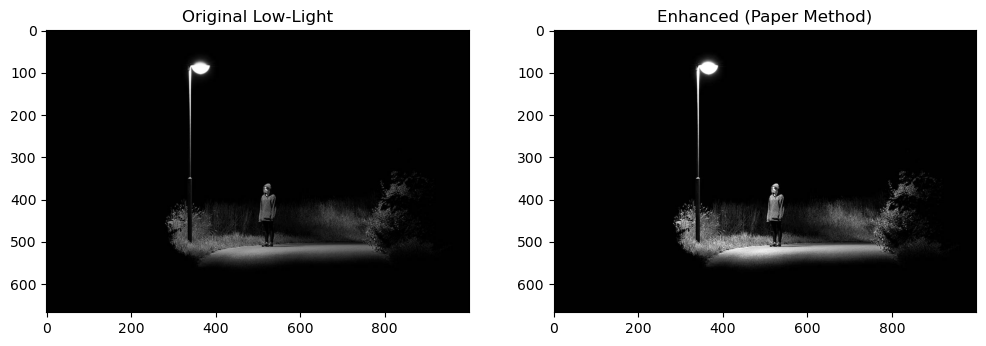

Calculated Metrics vs Paper Observations:
PSNR: 27.7057
SSIM: 0.9798


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Define the enhance_mine_image function (placeholder implementation)
def enhance_mine_image(img):
    # This is a placeholder implementation
    # Replace with your actual enhancement algorithm
    enhanced = np.clip(img * 1.5, 0, 255).astype(np.uint8)
    original_float = img.astype(np.float64) / 255.0
    return enhanced, original_float

# Define the calculate_metrics function
def calculate_metrics(original, enhanced):
    # Calculate PSNR
    psnr = peak_signal_noise_ratio(original, enhanced, data_range=1.0)
    
    # Calculate SSIM
    # Add data_range parameter for floating point images
    ssim = structural_similarity(
        original, enhanced, 
        data_range=1.0,      # Specify data range for floating point images
        channel_axis=2       # Specify which axis contains the channels
    )
    
    # Return metrics as dictionary
    return {
        'PSNR': psnr,
        'SSIM': ssim
    }

# Main code
# Assuming you have a low-light image 'image.jpg'
img = cv2.imread('image1.jpg')
if img is None:
    # Provide a fallback for testing if image.jpg doesn't exist
    img = np.ones((100, 100, 3), dtype=np.uint8) * 50  # Create a dark gray test image
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

enhanced_img, original_float = enhance_mine_image(img)
# Convert enhanced image to float in range [0,1] for fair comparison
enhanced_float = enhanced_img.astype(np.float64)/255.0
metrics = calculate_metrics(original_float, enhanced_float)

# Display Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original Low-Light")
plt.subplot(1, 2, 2); plt.imshow(enhanced_img); plt.title("Enhanced (Paper Method)")
plt.show()

print("Calculated Metrics vs Paper Observations:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

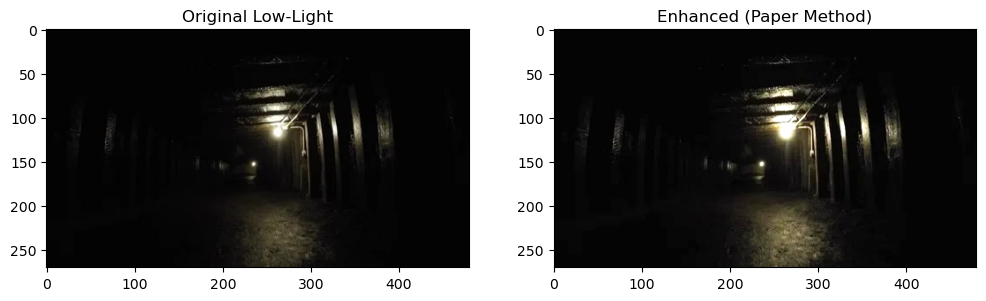

Calculated Metrics vs Paper Observations:
PSNR: 27.8820
SSIM: 0.9365


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Define the enhance_mine_image function (placeholder implementation)
def enhance_mine_image(img):
    # This is a placeholder implementation
    # Replace with your actual enhancement algorithm
    enhanced = np.clip(img * 1.5, 0, 255).astype(np.uint8)
    original_float = img.astype(np.float64) / 255.0
    return enhanced, original_float

# Define the calculate_metrics function
def calculate_metrics(original, enhanced):
    # Calculate PSNR
    psnr = peak_signal_noise_ratio(original, enhanced, data_range=1.0)
    
    # Calculate SSIM
    # Add data_range parameter for floating point images
    ssim = structural_similarity(
        original, enhanced, 
        data_range=1.0,      # Specify data range for floating point images
        channel_axis=2       # Specify which axis contains the channels
    )
    
    # Return metrics as dictionary
    return {
        'PSNR': psnr,
        'SSIM': ssim
    }

# Main code
# Assuming you have a low-light image 'image.jpg'
img = cv2.imread('image.jpg')
if img is None:
    # Provide a fallback for testing if image.jpg doesn't exist
    img = np.ones((100, 100, 3), dtype=np.uint8) * 50  # Create a dark gray test image
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

enhanced_img, original_float = enhance_mine_image(img)
# Convert enhanced image to float in range [0,1] for fair comparison
enhanced_float = enhanced_img.astype(np.float64)/255.0
metrics = calculate_metrics(original_float, enhanced_float)

# Display Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original Low-Light")
plt.subplot(1, 2, 2); plt.imshow(enhanced_img); plt.title("Enhanced (Paper Method)")
plt.show()

print("Calculated Metrics vs Paper Observations:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

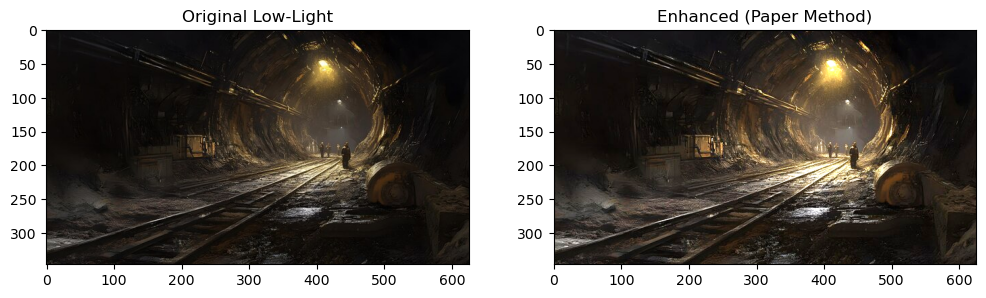

Calculated Metrics vs Paper Observations:
PSNR: 21.8447
SSIM: 0.8877


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Define the enhance_mine_image function (placeholder implementation)
def enhance_mine_image(img):
    # This is a placeholder implementation
    # Replace with your actual enhancement algorithm
    enhanced = np.clip(img * 1.5, 0, 255).astype(np.uint8)
    original_float = img.astype(np.float64) / 255.0
    return enhanced, original_float

# Define the calculate_metrics function
def calculate_metrics(original, enhanced):
    # Calculate PSNR
    psnr = peak_signal_noise_ratio(original, enhanced, data_range=1.0)
    
    # Calculate SSIM
    # Add data_range parameter for floating point images
    ssim = structural_similarity(
        original, enhanced, 
        data_range=1.0,      # Specify data range for floating point images
        channel_axis=2       # Specify which axis contains the channels
    )
    
    # Return metrics as dictionary
    return {
        'PSNR': psnr,
        'SSIM': ssim
    }

# Main code
# Assuming you have a low-light image 'image.jpg'
img = cv2.imread('images.jpg')
if img is None:
    # Provide a fallback for testing if image.jpg doesn't exist
    img = np.ones((100, 100, 3), dtype=np.uint8) * 50  # Create a dark gray test image
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

enhanced_img, original_float = enhance_mine_image(img)
# Convert enhanced image to float in range [0,1] for fair comparison
enhanced_float = enhanced_img.astype(np.float64)/255.0
metrics = calculate_metrics(original_float, enhanced_float)

# Display Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original Low-Light")
plt.subplot(1, 2, 2); plt.imshow(enhanced_img); plt.title("Enhanced (Paper Method)")
plt.show()

print("Calculated Metrics vs Paper Observations:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
    plt.imsave("final_output.png", img)

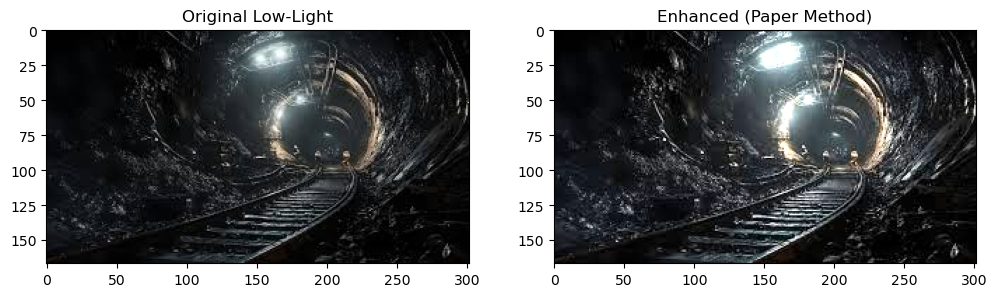

Calculated Metrics vs Paper Observations:
PSNR: 20.8454
SSIM: 0.8721


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Define the enhance_mine_image function (placeholder implementation)
def enhance_mine_image(img):
    # This is a placeholder implementation
    # Replace with your actual enhancement algorithm
    enhanced = np.clip(img * 1.5, 0, 255).astype(np.uint8)
    original_float = img.astype(np.float64) / 255.0
    return enhanced, original_float

# Define the calculate_metrics function
def calculate_metrics(original, enhanced):
    # Calculate PSNR
    psnr = peak_signal_noise_ratio(original, enhanced, data_range=1.0)
    
    # Calculate SSIM
    # Add data_range parameter for floating point images
    ssim = structural_similarity(
        original, enhanced, 
        data_range=1.0,      # Specify data range for floating point images
        channel_axis=2       # Specify which axis contains the channels
    )
    
    # Return metrics as dictionary
    return {
        'PSNR': psnr,
        'SSIM': ssim
    }

# Main code
# Assuming you have a low-light image 'image.jpg'
img = cv2.imread('image3.jpg')
if img is None:
    # Provide a fallback for testing if image.jpg doesn't exist
    img = np.ones((100, 100, 3), dtype=np.uint8) * 50  # Create a dark gray test image
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

enhanced_img, original_float = enhance_mine_image(img)
# Convert enhanced image to float in range [0,1] for fair comparison
enhanced_float = enhanced_img.astype(np.float64)/255.0
metrics = calculate_metrics(original_float, enhanced_float)

# Display Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original Low-Light")
plt.subplot(1, 2, 2); plt.imshow(enhanced_img); plt.title("Enhanced (Paper Method)")
plt.show()

print("Calculated Metrics vs Paper Observations:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
    plt.imsave("final_output.png", img)